In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


# MNIST Digits - Classification Using SVM

In this notebook, we'll explore the popular MNIST dataset and build an SVM model to classify handwritten digits. <a href='http://yann.lecun.com/exdb/mnist/'>Here is a detailed description of the dataset.</a>

We'll divide the analysis into the following parts:
- Data understanding and cleaning
- Data preparation for model building
- Building an SVM model - hyperparameter tuning, model evaluation etc.

# Loading Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

In [3]:
df_train = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
df_test = pd.read_csv("/kaggle/input/digit-recognizer/test.csv")

In [4]:
df_train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [6]:
df_train.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


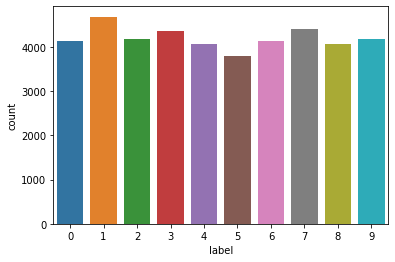

In [7]:
sns.countplot(x= df_train["label"]) # Almost balanced dataset
plt.show()

# Spliting into predictor and target

In [8]:
y_train = df_train.pop('label')
X_train = df_train

# Reshaping and scaling the predictors

In [9]:
X_train = X_train.values.reshape(-1, 28, 28, 1)
X_test = df_test.values.reshape(-1, 28, 28, 1)

In [10]:
X_train = X_train/255
X_test = X_test/255

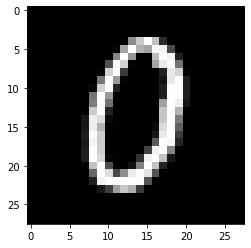

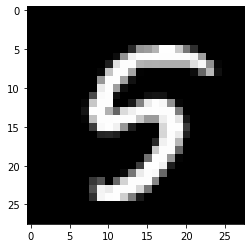

In [11]:
plt.imshow(X_train[5], cmap='gray')
plt.show()
plt.imshow(X_train[8], cmap='gray')
plt.show()

In [12]:
X_train.shape, y_train.shape

((42000, 28, 28, 1), (42000,))

# Model Building

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras import callbacks

In [14]:
model=Sequential([
    Conv2D(32, (5,5) , activation='relu' , input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    
    Conv2D(64,(5,5), activation ='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),
    
    Conv2D(64,(3,3), activation ='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [15]:
callback = callbacks.EarlyStopping(monitor='loss', patience=5)

In [16]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [17]:
model.fit(X_train, y_train, epochs=50, batch_size=64, callbacks=[callback])

Epoch 1/50
657/657 [==============================] - 7s 4ms/step - loss: 0.8164 - accuracy: 0.7229
Epoch 2/50
657/657 [==============================] - 3s 5ms/step - loss: 0.1276 - accuracy: 0.9604
Epoch 3/50
657/657 [==============================] - 3s 4ms/step - loss: 0.0859 - accuracy: 0.9735
Epoch 4/50
657/657 [==============================] - 3s 4ms/step - loss: 0.0634 - accuracy: 0.9811
Epoch 5/50
657/657 [==============================] - 3s 4ms/step - loss: 0.0581 - accuracy: 0.9810
Epoch 6/50
657/657 [==============================] - 3s 4ms/step - loss: 0.0471 - accuracy: 0.9858
Epoch 7/50
657/657 [==============================] - 3s 4ms/step - loss: 0.0400 - accuracy: 0.9883
Epoch 8/50
657/657 [==============================] - 3s 4ms/step - loss: 0.0325 - accuracy: 0.9908
Epoch 9/50
657/657 [==============================] - 3s 4ms/step - loss: 0.0361 - accuracy: 0.9888
Epoch 10/50
657/657 [==============================] - 3s 5ms/step - loss: 0.0350 - accuracy: 0.9892

# Model Predictions

In [18]:
y_test = model.predict(X_test)

In [19]:
y_test = np.argmax(y_test, axis = 1)

In [20]:
index_list = []
for i in list(df_test.index):
    index_list.append(i+1)

In [21]:
submission_df = pd.DataFrame({
    "ImageId": index_list,
    "Label": y_test
})

In [22]:
submission_df.to_csv("submission_cnn.csv", index = False)